<a href="https://colab.research.google.com/github/cauarichard/crud2/blob/main/separarcompesoscriado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Classes: ['brad pitt', 'faces_fake', 'faces_fake_completada', 'faces_fake_criadoai', 'faces_geral_real_fake', 'faces_real', 'faces_real_completada', 'fakes_criados']
Total de imagens usadas: 200
Missing keys: []
Unexpected keys: []
Pesos carregados no modelo FrozenCNN.
Features shape: (200, 84)
Labels shape: (200,)


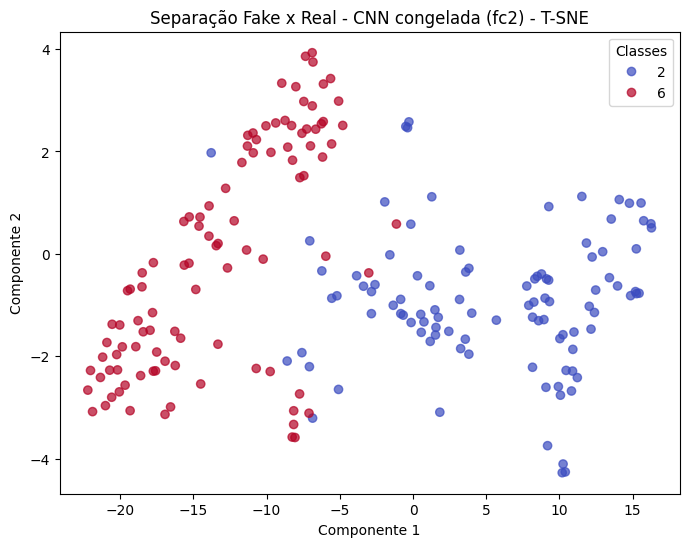

In [3]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from sklearn.manifold import TSNE
from PIL import Image
from torch.utils.data import Subset
import cv2
from google.colab import drive
import torch.nn as nn
import torch.nn.functional as F

# 1) Montar o Google Drive
drive.mount('/content/drive', force_remount=True)

# 2) Caminhos das pastas de imagem
BASE_PATH = '/content/drive/MyDrive/dataset/real_fake'
FAKES_FOLDER = 'faces_fake_completada'
REALS_FOLDER = 'faces_real_completada'

# 3) Caminho do arquivo .pth
PTH_PATH = '/content/drive/MyDrive/dataset/pesocongelado/faces_mlp_congelado.pth'

# 4) Loader OpenCV (tons de cinza)
def opencv_loader(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)   # 1 canal
    return Image.fromarray(img)

# 5) Transform — AGORA 28x28
transform = transforms.Compose([
    transforms.Resize((28, 28)),                   # <<< tamanho ajustado
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

# 6) Dataset binário (fake x real)
full_dataset = datasets.ImageFolder(
    root=BASE_PATH,
    transform=transform,
    loader=opencv_loader
)

indices = [
    i for i, (_, label) in enumerate(full_dataset.samples)
    if full_dataset.classes[label] in [FAKES_FOLDER, REALS_FOLDER]
]

binary_ds = Subset(full_dataset, indices)

print("Classes:", full_dataset.classes)
print("Total de imagens usadas:", len(binary_ds))

# 7) Rede compatível com o state_dict
class FrozenCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool = nn.MaxPool2d(2, 2)
        # conforme o seu state_dict: fc1.weight [120, 256]
        self.fc1 = nn.Linear(16 * 4 * 4, 120)   # 16*4*4 = 256
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))    # -> [B, 6, 12, 12]
        x = self.pool(F.relu(self.conv2(x)))    # -> [B, 16, 4, 4]
        x = x.view(x.size(0), -1)               # -> [B, 256]
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FrozenCNN().to(DEVICE)

# 8) Carregar pesos
state = torch.load(PTH_PATH, map_location=DEVICE)
missing, unexpected = model.load_state_dict(state, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)
print("Pesos carregados no modelo FrozenCNN.")

model.eval()

# 9) Extrair features da fc2
def extract_features(dataset, model, device):
    features, labels = [], []

    with torch.no_grad():
        for img, label in dataset:
            img = img.unsqueeze(0).to(device)   # [1, 1, 28, 28]
            x = model.pool(F.relu(model.conv1(img)))
            x = model.pool(F.relu(model.conv2(x)))
            x = x.view(x.size(0), -1)
            x = F.relu(model.fc1(x))
            x = F.relu(model.fc2(x))           # [1, 84]
            features.append(x.cpu().numpy())
            labels.append(label)

    return np.concatenate(features), np.array(labels)

features, labels = extract_features(binary_ds, model, DEVICE)
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

# 10) T-SNE
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(features)

# 11) Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=labels, cmap='coolwarm', alpha=0.7
)
plt.title("Separação Fake x Real - CNN congelada (fc2) - T-SNE")
plt.legend(*scatter.legend_elements(), title="Classes")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()


Mounted at /content/drive
Classes completas do ImageFolder: ['brad pitt', 'faces_fake', 'faces_fake_completada', 'faces_fake_criadoai', 'faces_geral_real_fake', 'faces_real', 'faces_real_completada', 'fakes_criados']
class_to_idx: {'brad pitt': 0, 'faces_fake': 1, 'faces_fake_completada': 2, 'faces_fake_criadoai': 3, 'faces_geral_real_fake': 4, 'faces_real': 5, 'faces_real_completada': 6, 'fakes_criados': 7}
Total de imagens usadas (fake + real): 200
Missing keys: []
Unexpected keys: []
Pesos carregados no modelo FrozenCNN.
Features shape: (200, 84)
Labels shape: (200,)
Valores únicos brutos de labels: [2 6]
Mapeando rótulo 2 -> 0 e 6 -> 1
Valores únicos após mapeamento: [0 1]


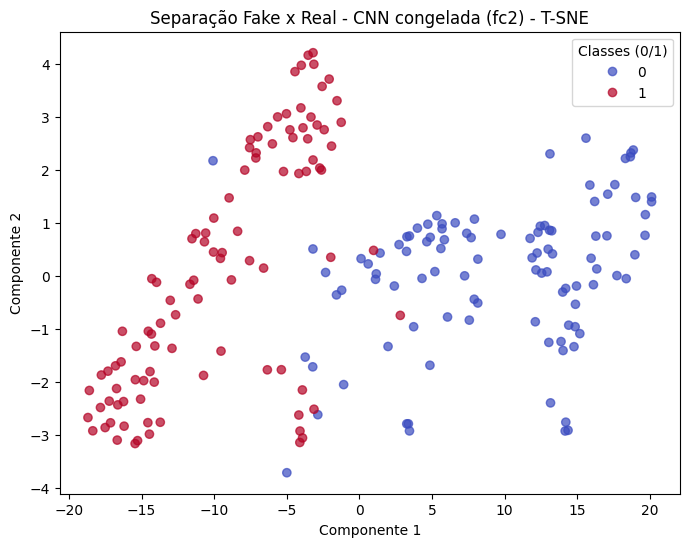

Valores únicos em y_true_raw: [2 6]
Valores únicos em y_pred    : [0 1]
Mapeando rótulo 2 -> 0 e 6 -> 1 nos y_true
Valores únicos em y_true (mapeado): [0 1]

===== MÉTRICAS DO MODELO =====
Accuracy : 0.755
Precision: 0.9811320754716981
Recall   : 0.52
F1 Score : 0.6797385620915033

===== MATRIZ DE CONFUSÃO =====
[[99  1]
 [48 52]]

===== RELATÓRIO COMPLETO =====
              precision    recall  f1-score   support

           0     0.6735    0.9900    0.8016       100
           1     0.9811    0.5200    0.6797       100

    accuracy                         0.7550       200
   macro avg     0.8273    0.7550    0.7407       200
weighted avg     0.8273    0.7550    0.7407       200



In [6]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from sklearn.manifold import TSNE
from PIL import Image
from torch.utils.data import Subset, DataLoader
import cv2
from google.colab import drive
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 1) Montar o Google Drive
drive.mount('/content/drive', force_remount=True)

# 2) Caminhos das pastas de imagem
BASE_PATH = '/content/drive/MyDrive/dataset/real_fake'
FAKES_FOLDER = 'faces_fake_completada'
REALS_FOLDER = 'faces_real_completada'

# 3) Caminho do arquivo .pth
PTH_PATH = '/content/drive/MyDrive/dataset/pesocongelado/faces_mlp_congelado.pth'

# 4) Loader OpenCV (tons de cinza)
def opencv_loader(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)   # 1 canal
    return Image.fromarray(img)

# 5) Transform — 28x28
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

# 6) Dataset binário (fake x real)
full_dataset = datasets.ImageFolder(
    root=BASE_PATH,
    transform=transform,
    loader=opencv_loader
)

print("Classes completas do ImageFolder:", full_dataset.classes)
print("class_to_idx:", full_dataset.class_to_idx)

# Filtrar só as duas pastas desejadas
indices = [
    i for i, (_, label) in enumerate(full_dataset.samples)
    if full_dataset.classes[label] in [FAKES_FOLDER, REALS_FOLDER]
]

binary_ds = Subset(full_dataset, indices)

print("Total de imagens usadas (fake + real):", len(binary_ds))

# 7) Rede compatível com o state_dict
class FrozenCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)   # 16*4*4 = 256
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 1)             # saída escalar (logit)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))    # -> [B, 6, 12, 12]
        x = self.pool(F.relu(self.conv2(x)))    # -> [B, 16, 4, 4]
        x = x.view(x.size(0), -1)               # -> [B, 256]
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FrozenCNN().to(DEVICE)

# 8) Carregar pesos
state = torch.load(PTH_PATH, map_location=DEVICE)
missing, unexpected = model.load_state_dict(state, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)
print("Pesos carregados no modelo FrozenCNN.")

model.eval()

# 9) Função para extrair features da fc2
def extract_features(dataset, model, device, batch_size=64):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    features_list = []
    labels_list = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)        # [B, 1, 28, 28]

            x = model.pool(F.relu(model.conv1(imgs)))
            x = model.pool(F.relu(model.conv2(x)))
            x = x.view(x.size(0), -1)
            x = F.relu(model.fc1(x))
            x = F.relu(model.fc2(x))      # [B, 84]

            features_list.append(x.cpu().numpy())
            labels_list.append(labels.cpu().numpy())

    features = np.concatenate(features_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    return features, labels

features, labels = extract_features(binary_ds, model, DEVICE)
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)
print("Valores únicos brutos de labels:", np.unique(labels))

# --- REMAPEAMENTO DOS RÓTULOS ---
# Aqui assumimos que os dois valores únicos são, por exemplo, [2, 6] (fake e real).
unique_labels = np.unique(labels)
assert len(unique_labels) == 2, "Esperado exatamente 2 classes no subset."

label_a = unique_labels[0]  # vai virar 0
label_b = unique_labels[1]  # vai virar 1

labels_mapped = np.where(labels == label_a, 0, 1)
print(f"Mapeando rótulo {label_a} -> 0 e {label_b} -> 1")
print("Valores únicos após mapeamento:", np.unique(labels_mapped))

# 10) T-SNE usando labels remapeados
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(features)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=labels_mapped, cmap='coolwarm', alpha=0.7
)
plt.title("Separação Fake x Real - CNN congelada (fc2) - T-SNE")
plt.legend(*scatter.legend_elements(), title="Classes (0/1)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

# 11) Avaliação do modelo
def evaluate_model(dataset, model, device, label_a, label_b, batch_size=64):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    y_true_raw = []
    y_pred = []

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)

            outputs = model(imgs)              # [B, 1]
            probs = torch.sigmoid(outputs)     # [B, 1] entre 0 e 1
            preds = (probs > 0.5).int().cpu().numpy().flatten()

            y_true_raw.extend(labels.cpu().numpy())
            y_pred.extend(preds)

    y_true_raw = np.array(y_true_raw)
    y_pred = np.array(y_pred)

    print("Valores únicos em y_true_raw:", np.unique(y_true_raw))
    print("Valores únicos em y_pred    :", np.unique(y_pred))

    # Remapear rótulos verdadeiros para 0/1 igual fizemos acima
    y_true = np.where(y_true_raw == label_a, 0, 1)
    print(f"Mapeando rótulo {label_a} -> 0 e {label_b} -> 1 nos y_true")
    print("Valores únicos em y_true (mapeado):", np.unique(y_true))

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='binary')
    recall = recall_score(y_true, y_pred, average='binary')
    f1 = f1_score(y_true, y_pred, average='binary')
    cm = confusion_matrix(y_true, y_pred)

    print("\n===== MÉTRICAS DO MODELO =====")
    print("Accuracy :", acc)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\n===== MATRIZ DE CONFUSÃO =====")
    print(cm)

    print("\n===== RELATÓRIO COMPLETO =====")
    print(classification_report(y_true, y_pred, digits=4))

# Chamada da avaliação usando o mesmo mapeamento dos labels
evaluate_model(binary_ds, model, DEVICE, label_a, label_b)
